# Ejercicio 8 — Incorporación de 2025 y análisis completo

Al terminar este ejercicio el sistema trabaja de forma reproducible con taxis amarillos y verdes de **2024, 2025 y 2026**. Consultas: [`sql/08_evolucion.sql`](../sql/08_evolucion.sql).

## 8.1 Modificación del sistema de descarga

2025 se agregó a la lista de años por defecto del script (`ANIOS = (2024, 2025, 2026)` en [`scripts/download_data.py`](../scripts/download_data.py)), así que la descarga completa ya no necesita argumentos:

```bash
docker compose exec lab python scripts/download_data.py
```

Salida resumida de la ejecución:

```text
=== YELLOW 2024 ===
  2024-01  ya existe, se omite
  ...                                  (12 meses)
=== GREEN 2024 ===                     (12 meses, ya existen)
=== YELLOW 2025 ===
  2025-01  listo (56.4 MiB) -> data/raw/yellow/2025/yellow_tripdata_2025-01.parquet
  ...                                  (12 meses, 56.4 a 74.2 MiB cada uno)
=== GREEN 2025 ===
  2025-01  listo (1.1 MiB) -> data/raw/green/2025/green_tripdata_2025-01.parquet
  ...                                  (12 meses, 1.1 a 1.3 MiB cada uno)
=== YELLOW 2026 ===
  2026-01  ya existe, se omite
  ...                                  (2026-01 a 2026-08)
  2026-09  aun no publicado por la TLC
  ...                                  (2026-09 a 2026-12)
=== GREEN 2026 ===                     (igual que amarillos)
RESUMEN
  descargados   : 24
  ya existian   : 40
  no publicados : 8
  fallidos      : 0
```

## 8.2 Los archivos previos no se descargaron de nuevo

Los 40 archivos de 2024 y 2026 aparecen como `ya existe, se omite`: el script no consulta el servidor por ellos. Solo se descargaron los 24 de 2025.

In [1]:
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../scripts")
from lab import conectar_parquet, conectar_tabla, consultas, mostrar

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
con = conectar_parquet()
Q = consultas("08_evolucion.sql")

In [2]:
mostrar(con, Q["8.2_archivos_por_anio"])

-- Objetivo: verificar los archivos de cada tipo y anio despues de agregar 2025.
-- Fuente: nombres de archivo de data/raw/*/*/*.parquet (glob).
SELECT regexp_extract(file, 'raw/(\w+)/', 1)                         AS tipo_taxi,
       CAST(regexp_extract(file, 'raw/\w+/(\d{4})/', 1) AS INTEGER)  AS anio,
       count(*)                                                      AS archivos,
       min(regexp_extract(file, '(\d{4}-\d{2})\.parquet$', 1))       AS primer_mes,
       max(regexp_extract(file, '(\d{4}-\d{2})\.parquet$', 1))       AS ultimo_mes
FROM glob('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY tipo_taxi, anio;


,tipo_taxi,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2025,12,2025-01,2025-12
2,green,2026,8,2026-01,2026-08
3,yellow,2024,12,2024-01,2024-12
4,yellow,2025,12,2025-01,2025-12
5,yellow,2026,8,2026-01,2026-08


In [3]:
mostrar(con, Q["8.2_registros_por_anio"])

-- Objetivo: registros por tipo y anio segun los metadatos de cada archivo.
-- Fuente: metadatos de data/raw/*/*/*.parquet (parquet_file_metadata).
SELECT regexp_extract(file_name, 'raw/(\w+)/', 1)                        AS tipo_taxi,
       CAST(regexp_extract(file_name, 'raw/\w+/(\d{4})/', 1) AS INTEGER) AS anio,
       count(*)                                                          AS archivos,
       sum(num_rows)::BIGINT                                             AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY tipo_taxi, anio;


,tipo_taxi,anio,archivos,registros
0,green,2024,12,660218
1,green,2025,12,591375
2,green,2026,8,337114
3,yellow,2024,12,41169720
4,yellow,2025,12,48722602
5,yellow,2026,8,29703355


**Resultado:** 2024 y 2025 tienen sus 12 meses por tipo y 2026 sus 8 meses publicados: 64 archivos y 121,184,384 registros en total. 2025 tiene 48.7 millones de viajes amarillos, el año con más viajes de los tres.

## 8.3 Las consultas desarrolladas siguen funcionando

Se ejecutan **todas** las consultas de los ejercicios anteriores, sin modificarlas, sobre el conjunto ampliado: las de los Ejercicios 3, 4, 5 y 8 sobre los Parquet, y las del tablero (Ejercicio 7) tanto sobre los Parquet como sobre la tabla materializada que usa Metabase:

In [4]:
tabla = conectar_tabla()
filas = []
for archivo, conexion, fuente in [("03_exploracion.sql", con, "Parquet"),
                                  ("04_analisis_exploratorio.sql", con, "Parquet"),
                                  ("05_incorporacion_2024.sql", con, "Parquet"),
                                  ("07_indicadores.sql", con, "Parquet"),
                                  ("07_indicadores.sql", tabla, "tabla DuckDB"),
                                  ("08_evolucion.sql", con, "Parquet")]:
    for nombre, sql in consultas(archivo).items():
        inicio = time.perf_counter()
        try:
            resultado, estado = len(conexion.sql(sql).fetchall()), "ok"
        except Exception as error:
            resultado, estado = None, f"ERROR: {error}"
        filas.append((archivo, nombre, fuente, resultado, round(time.perf_counter() - inicio, 2), estado))

verificacion = pd.DataFrame(filas, columns=["archivo", "consulta", "fuente", "filas", "segundos", "estado"])
print(verificacion["estado"].value_counts().to_string())
verificacion

estado
ok    64


,archivo,consulta,fuente,filas,segundos,estado
0,03_exploracion.sql,3.1_archivos,Parquet,2,0.05,ok
1,03_exploracion.sql,3.2_registros_por_archivo,Parquet,16,0.08,ok
2,03_exploracion.sql,3.2_registros_total,Parquet,2,0.12,ok
3,03_exploracion.sql,3.3_columnas_yellow,Parquet,21,0.04,ok
4,03_exploracion.sql,3.3_columnas_green,Parquet,22,0.04,ok
5,03_exploracion.sql,3.4_esquema_por_archivo,Parquet,2,0.11,ok
6,03_exploracion.sql,3.5_muestra_yellow,Parquet,5,0.24,ok
7,03_exploracion.sql,3.5_muestra_green,Parquet,5,0.14,ok
8,03_exploracion.sql,3.6_nulos,Parquet,2,7.44,ok
9,03_exploracion.sql,3.6_incompletos_por_pago,Parquet,11,1.23,ok


**Resultado:** todas las consultas se ejecutan sin errores sobre los tres años y ninguna necesitó cambios. Las de los Ejercicios 3–5 devuelven lo mismo que antes porque tienen un año fijo (era su alcance); las del tablero y las de este ejercicio agrupan por `anio` y ahora incluyen 2025 automáticamente.

## 8.4 Actualización de indicadores y visualizaciones

Las consultas del tablero ([`sql/07_indicadores.sql`](../sql/07_indicadores.sql)) no fijan años, así que para actualizarlo solo hubo que reconstruir la tabla que lee Metabase:

```bash
docker compose stop metabase
docker compose exec lab python scripts/materializar.py      # 121,184,384 registros en ~31 s
docker compose start metabase
```

Tablero con 2024 y 2026 (Ejercicio 7):

![Tablero 2024 y 2026](../docs/img/tablero_2024_2026.png)

Tablero con 2024, 2025 y 2026, sin cambios en ninguna consulta:

![Tablero 2024-2026](../docs/img/tablero_2024_2025_2026.png)

## 8.5 Evolución de los indicadores

Como 2026 solo llega hasta agosto, la comparación anual usa **los mismos meses (enero–agosto) de cada año**. La consulta calcula ese límite a partir del último mes publicado, así que se ajusta sola cuando la TLC publique más meses.

In [5]:
anual = mostrar(con, Q["8.5_indicadores_anuales"])
anual.set_index(["tipo_taxi", "anio"]).T

-- Objetivo: valor de los indicadores principales por anio y tipo, en los meses comparables.
-- Fuente: vista `viajes_validos`.
SELECT anio,
       tipo_taxi,
       count(*)                                                              AS viajes,
       round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)))       AS viajes_por_dia,
       round(avg(total_amount), 2)                                           AS ticket_promedio_usd,
       round(sum(fare_amount) / sum(trip_distance), 2)                       AS tarifa_por_milla,
       round(median(trip_distance), 2)                                       AS distancia_mediana_mi,
       round(median(duracion_min), 1)                                        AS duracion_mediana_min,
       round(median(velocidad_mph), 2)                                       AS velocidad_mediana_mph,
       round(100.0 * count_if(forma_pago = 'Tarjeta') / count(*), 1)         AS pct_tarjeta,
       round(100.0 * count_if(forma_pago = 'Efectivo') / c

tipo_taxi                  green                             yellow  \
anio                        2024       2025       2026         2024   
viajes                 415519.00  371698.00  316783.00  25485040.00   
viajes_por_dia           1703.00    1530.00    1304.00    104447.00   
ticket_promedio_usd        23.71      24.81      25.29        28.32   
tarifa_por_milla            6.08       5.81       5.15         5.71   
distancia_mediana_mi        1.96       2.02       2.12         1.80   
duracion_mediana_min       11.90      12.40      13.20        12.70   
velocidad_mediana_mph      10.38      10.29      10.03         9.51   
pct_tarjeta                67.80      70.00      66.60        75.90   
pct_efectivo               27.80      23.20      19.70        13.80   
pct_flex_sin_dato           0.00       0.00       0.00         9.00   
pct_aeropuerto              4.15       3.66       3.40        10.16   
pct_con_cargo_cbd            NaN       9.80       8.50          NaN   

tipo_taxi                                        
anio                          2025         2026  
viajes                 28676474.00  28212241.00  
viajes_por_dia           118010.00    116100.00  
ticket_promedio_usd          28.38        30.24  
tarifa_por_milla              5.69         6.07  
distancia_mediana_mi          1.88         1.93  
duracion_mediana_min         13.00        14.10  
velocidad_mediana_mph         9.66         9.28  
pct_tarjeta                  68.70        65.40  
pct_efectivo                 10.00         9.10  
pct_flex_sin_dato            19.60        24.90  
pct_aeropuerto                8.90         8.16  
pct_con_cargo_cbd            73.00        72.40

In [6]:
mostrar(con, Q["8.5_variacion_anual"])

-- Objetivo: variacion porcentual de cada indicador respecto del anio anterior (meses comparables).
-- Fuente: vista `viajes_validos`.
WITH anual AS (
    SELECT anio,
           tipo_taxi,
           count(*) / count(DISTINCT CAST(pickup_datetime AS DATE))  AS viajes_por_dia,
           avg(total_amount)                                         AS ticket,
           sum(fare_amount) / sum(trip_distance)                     AS tarifa_por_milla,
           median(duracion_min)                                      AS duracion_mediana,
           median(velocidad_mph)                                     AS velocidad_mediana
    FROM viajes_validos
    WHERE mes <= (SELECT max(mes) FROM viajes WHERE anio = (SELECT max(anio) FROM viajes))
    GROUP BY anio, tipo_taxi
)
SELECT anio,
       tipo_taxi,
       round(100 * (viajes_por_dia    / lag(viajes_por_dia)    OVER w - 1), 1) AS var_viajes_por_dia,
       round(100 * (ticket            / lag(ticket)            OVER w - 1), 1) AS var_ticket,

,anio,tipo_taxi,var_viajes_por_dia,var_ticket,var_tarifa_por_milla,var_duracion,var_velocidad
0,2025,green,-10.2,4.7,-4.4,4.6,-0.9
1,2026,green,-14.8,1.9,-11.5,6.6,-2.5
2,2025,yellow,13.0,0.2,-0.4,2.2,1.5
3,2026,yellow,-1.6,6.6,6.7,8.5,-3.9


-- Objetivo: viajes promedio por dia en cada mes, para superponer los tres anios.
-- Fuente: vista `viajes_validos`.
SELECT anio,
       mes,
       tipo_taxi,
       round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE))) AS viajes_por_dia
FROM viajes_validos
GROUP BY ALL
ORDER BY ALL;


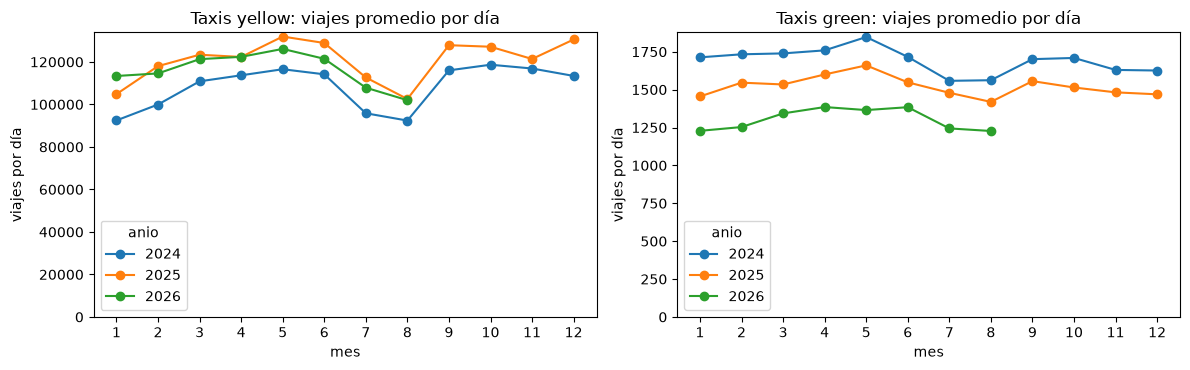

In [7]:
mensual = mostrar(con, Q["8.5_viajes_por_dia_mensual"])
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    datos = mensual[mensual["tipo_taxi"] == tipo].pivot(index="mes", columns="anio", values="viajes_por_dia")
    datos.plot(ax=eje, marker="o", title=f"Taxis {tipo}: viajes promedio por día", xticks=range(1, 13))
    eje.set(xlabel="mes", ylabel="viajes por día")
    eje.set_ylim(bottom=0)
plt.tight_layout()

**Resultado (enero–agosto de cada año):**

| Indicador | Amarillos 2024 → 2025 → 2026 | Verdes 2024 → 2025 → 2026 |
|---|---|---|
| Viajes por día | 104,447 → 118,010 → 116,100 | 1,703 → 1,530 → 1,304 |
| Ticket promedio (USD) | 28.32 → 28.38 → 30.24 | 23.71 → 24.81 → 25.29 |
| Tarifa por milla (USD) | 5.71 → 5.69 → 6.07 | 6.08 → 5.81 → 5.15 |
| Duración mediana (min) | 12.7 → 13.0 → 14.1 | 11.9 → 12.4 → 13.2 |
| Velocidad mediana (mph) | 9.51 → 9.66 → 9.28 | 10.38 → 10.29 → 10.03 |
| Pago con tarjeta (%) | 75.9 → 68.7 → 65.4 | 67.8 → 70.0 → 66.6 |
| Pago "Flex fare / sin dato" (%) | 9.0 → 19.6 → 24.9 | 0 → 0 → 0 |
| Viajes de/hacia aeropuertos (%) | 10.16 → 8.90 → 8.16 | 4.15 → 3.66 → 3.40 |
| Viajes con cargo CBD (%) | — → 73.0 → 72.4 | — → 9.8 → 8.5 |

La serie mensual repite cada año la misma estacionalidad (baja en enero, febrero, julio y agosto). Sobre ese patrón, los amarillos de 2025 están por encima de 2024 en todos los meses y 2026 queda cerca de 2025, mientras que los verdes bajan año tras año en todos los meses.

## 8.6 Cambios y patrones visibles al considerar los tres años

-- Objetivo: evolucion mensual de la forma de pago de los taxis amarillos.
-- Fuente: vista `viajes_validos`.
SELECT make_date(anio, mes, 1)                                                        AS periodo,
       round(100.0 * count_if(forma_pago = 'Tarjeta') / count(*), 1)                  AS pct_tarjeta,
       round(100.0 * count_if(forma_pago = 'Efectivo') / count(*), 1)                 AS pct_efectivo,
       round(100.0 * count_if(forma_pago = 'Flex fare / sin dato') / count(*), 1)     AS pct_flex_sin_dato
FROM viajes_validos
WHERE tipo_taxi = 'yellow'
GROUP BY ALL
ORDER BY ALL;


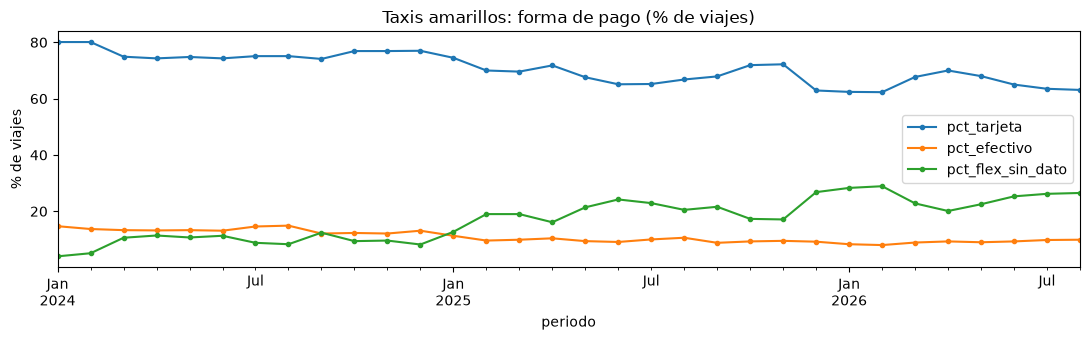

In [8]:
pago = mostrar(con, Q["8.6_forma_pago_mensual"])
pago.set_index("periodo").plot(figsize=(11, 3.5), marker=".", title="Taxis amarillos: forma de pago (% de viajes)")
plt.ylabel("% de viajes")
plt.tight_layout()

In [9]:
cbd = mostrar(con, Q["8.6_cargo_cbd_mensual"])
cbd[cbd["periodo"].between("2024-11-01", "2025-03-01")]

-- Objetivo: desde cuando y en que proporcion de viajes se cobra el cargo por congestion de Manhattan (CBD).
-- Fuente: vista `viajes_validos`.
SELECT make_date(anio, mes, 1)                                            AS periodo,
       tipo_taxi,
       round(100.0 * count_if(cbd_congestion_fee > 0) / count(*), 1)    AS pct_con_cargo_cbd,
       round(avg(cbd_congestion_fee) FILTER (cbd_congestion_fee > 0), 2) AS cargo_cbd_usd
FROM viajes_validos
GROUP BY ALL
ORDER BY tipo_taxi, periodo;


,periodo,tipo_taxi,pct_con_cargo_cbd,cargo_cbd_usd
10,2024-11-01,green,NaN,NaN
11,2024-12-01,green,NaN,NaN
12,2025-01-01,green,7.2,0.75
13,2025-02-01,green,8.8,0.75
14,2025-03-01,green,10.0,0.75
42,2024-11-01,yellow,NaN,NaN
43,2024-12-01,yellow,NaN,NaN
44,2025-01-01,yellow,65.8,0.75
45,2025-02-01,yellow,74.1,0.75
46,2025-03-01,yellow,74.3,0.75


In [10]:
mostrar(con, Q["8.6_origen_solicitud"])

-- Objetivo: como se solicitan los viajes desde que existe la columna request_source (2026-06).
-- Fuente: vista `viajes`.
SELECT tipo_taxi,
       coalesce(request_source, 'NULL (sin dato)')                                  AS request_source,
       count(*)                                                                    AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2)    AS pct_del_tipo
FROM viajes
WHERE make_date(anio, mes, 1) >= DATE '2026-06-01'
GROUP BY tipo_taxi, request_source
ORDER BY tipo_taxi, viajes DESC;


,tipo_taxi,request_source,viajes,pct_del_tipo
0,green,NULL (sin dato),106891,84.77
1,green,A,18029,14.30
2,green,HV0005,1179,0.93
3,green,CC,3,0.00
4,yellow,NULL (sin dato),7800627,72.88
5,yellow,HV0003,2295520,21.45
6,yellow,A,403773,3.77
7,yellow,HV0005,181233,1.69
8,yellow,EH0004,20769,0.19
9,yellow,CC,1879,0.02


1. **Los amarillos crecieron y los verdes siguen cayendo.** Los viajes amarillos por día subieron 13.0% de 2024 a 2025 y se mantuvieron en 2026 (−1.6%). Los verdes cayeron 10.2% y luego 14.8%, de 1,703 a 1,304 viajes por día, y su participación bajó de ~1.6% a ~1.1% del total (indicador I2 del tablero). Con un solo año no se distinguía si la caída de los verdes era un mal año o una tendencia; con tres años es una tendencia sostenida.
2. **El cargo por congestión de Manhattan (CBD) aparece en enero de 2025.** La columna `cbd_congestion_fee` no existe en 2024. Desde enero de 2025 se cobran USD 0.75 en ~73% de los viajes amarillos y ~10% de los verdes, y el patrón no cambia en 2026. Ese cargo agrega un componente nuevo al total (1.8% de lo cobrado en amarillos, indicador I4). La velocidad mediana de los amarillos subió 1.5% en 2025 y bajó 3.9% en 2026, así que con estos datos no se observa un efecto sostenido sobre la velocidad.
3. **Los datos de forma de pago se degradan.** Los viajes amarillos con `payment_type = 0` y cinco columnas en NULL pasaron de 9.0% (2024) a 19.6% (2025) y 24.9% (2026), y en algunos meses superan el 28%. En paralelo, la tarjeta bajó de 75.9% a 65.4% y el efectivo de 13.8% a 9.1%. Una parte creciente de los viajes no informa cómo se pagó, y esto sesga a la baja cualquier indicador de propina o forma de pago (de ahí que la propina se mida solo con tarjeta). La calidad general también tuvo un bache: entre mayo y noviembre de 2025 solo 87–90% de los registros pasó las reglas de calidad, por un aumento de tarifas o totales no positivos (indicador I10 del tablero), y en 2026 se recuperó a 94–96%.
4. **2026 es más caro y más lento.** En los amarillos, el ticket promedio subió 6.6% y la tarifa por milla 6.7% en 2026, después de estar estables en 2025. La duración mediana subió 8.5% aunque la distancia mediana casi no cambió (1.88 → 1.93 millas).
5. **Nuevo origen de las solicitudes.** Desde junio de 2026 la TLC publica `request_source`: el 21.5% de los viajes amarillos de junio–agosto tiene el código `HV0003` y el 1.7% `HV0005`, que en el diccionario de viajes FHV de alto volumen de la TLC corresponden a las licencias de Uber y Lyft. Esto indica viajes de taxi amarillo solicitados por esas aplicaciones. El resto de códigos (`A`, `CC`, `EH0004`, `EH0010`) no está documentado en el diccionario de datos que conocemos.

## 8.7 Consultas utilizadas

| Consulta (`sql/08_evolucion.sql`) | Objetivo | Fuente |
|---|---|---|
| `8.2_archivos_por_anio` | Archivos por tipo y año después de agregar 2025 | nombres de `data/raw/*/*/*.parquet` |
| `8.2_registros_por_anio` | Registros por tipo y año (metadatos) | metadatos de `data/raw/*/*/*.parquet` |
| `8.5_indicadores_anuales` | Indicadores por año en meses comparables | vista `viajes_validos` |
| `8.5_variacion_anual` | Variación % respecto del año anterior | vista `viajes_validos` |
| `8.5_viajes_por_dia_mensual` | Serie mensual superpuesta por año | vista `viajes_validos` |
| `8.6_forma_pago_mensual` | Evolución de la forma de pago (amarillos) | vista `viajes_validos` |
| `8.6_cargo_cbd_mensual` | Inicio y alcance del cargo CBD | vista `viajes_validos` |
| `8.6_origen_solicitud` | Origen de la solicitud desde 2026-06 | vista `viajes` |

La verificación de 8.3 reutiliza sin cambios todas las consultas de `sql/03_*.sql`, `sql/04_*.sql`, `sql/05_*.sql` y `sql/07_*.sql`.